<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 24px;">Observational Analysis: ERA5</h2>
</div>

In [1]:
import xarray as xr

ds = xr.open_dataset("/data/oacd/obs/ERA5/combined_2000_2004.nc")
print(ds)

<xarray.Dataset> Size: 38GB
Dimensions:     (latitude: 721, longitude: 1440, valid_time: 1827, time: 5)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * valid_time  (valid_time) datetime64[ns] 15kB 2000-01-01 ... 2004-12-31
    number      int64 8B ...
Dimensions without coordinates: time
Data variables:
    tp          (time, valid_time, latitude, longitude) float32 38GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-03-11T05:20 GRIB to CDM+CF via cfgrib-0.9.1...


In [2]:
ls /data/oacd/obs/ERA5/

combined_1940_1944.nc  combined_1975_1979.nc  combined_2010_2014.nc
combined_1945_1949.nc  combined_1980_1984.nc  combined_2015_2019.nc
combined_1950_1954.nc  combined_1985_1989.nc  combined_2020_2024.nc
combined_1955_1959.nc  combined_1990_1994.nc  combined_2025_2025.nc
combined_1960_1964.nc  combined_1995_1999.nc  location_checks/
combined_1965_1969.nc  combined_2000_2004.nc
combined_1970_1974.nc  combined_2005_2009.nc


In [ ]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("/data/oacd/obs/ERA5/combined_1980_1984.nc")

# Collapse the redundant time dimension by taking the max
# Since only one slice has real data per day, max() selects the real value
pr = ds['tp'].max(dim='time')

print(f'Shape after collapsing time dimension: {dict(pr.sizes)}')

# Verify it worked - July 15 1982 Kerala should be 4.402mm
july_idx = 926
val = float(pr.isel(valid_time=july_idx).sel(
    latitude=10, longitude=75, method='nearest'
).values) * 1000
print(f'Kerala July 15 1982: {val:.3f} mm')

# Check for NaNs in India domain
pr_india = pr.sel(latitude=slice(32, 8), longitude=slice(68, 97))
nan_count = int(np.isnan(pr_india.values).sum())
print(f'NaN count in India after collapse: {nan_count}')

In [ ]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("/data/oacd/obs/ERA5/combined_1980_1984.nc")
pr = ds['tp'].max(dim='time') * 1000  # convert to mm

# Select India domain
pr_india = pr.sel(latitude=slice(32, 8), longitude=slice(68, 97))

# Test 1: Check known monsoon months have higher rainfall than dry months
print('Test 1: Monsoon vs dry season contrast')
# Average daily rainfall over India for each month
for month_name, month_idx_range in [('January (dry)', range(0, 31)), 
                                      ('July (peak monsoon)', range(365+181, 365+212))]:
    mean_val = float(pr_india.isel(valid_time=list(month_idx_range)).mean())
    print(f'  Mean daily rainfall over India in {month_name}: {mean_val:.2f} mm')

# Test 2: Check Western Ghats gets more rain than Rajasthan
print('\nTest 2: Spatial pattern check (JJAS mean)')
# JJAS indices for 1980
jjas_1980 = [i for i in range(365) if 
             ds.valid_time.values[i].astype('datetime64[M]').astype(int) % 12 + 1 in [6,7,8,9]]

western_ghats = float(pr_india.sel(latitude=12, longitude=75, method='nearest'
                                    ).isel(valid_time=jjas_1980).mean())
rajasthan = float(pr_india.sel(latitude=27, longitude=73, method='nearest'
                                ).isel(valid_time=jjas_1980).mean())
igp = float(pr_india.sel(latitude=26, longitude=82, method='nearest'
                          ).isel(valid_time=jjas_1980).mean())

print(f'  Western Ghats (lat=12, lon=75) JJAS mean: {western_ghats:.2f} mm/day')
print(f'  Rajasthan (lat=27, lon=73) JJAS mean: {rajasthan:.2f} mm/day')
print(f'  IGP (lat=26, lon=82) JJAS mean: {igp:.2f} mm/day')
print(f'  Western Ghats should be highest, Rajasthan lowest')

# Test 3: Annual total over India looks reasonable
print('\nTest 3: Annual total rainfall 1980')
annual_1980 = float(pr_india.isel(valid_time=range(365)).sum(dim='valid_time').mean())
print(f'  Mean annual total over India domain: {annual_1980:.0f} mm')
print(f'  Expected range: 500-3000mm depending on region, ~1000mm average')

# Test 4: No negative values
print('\nTest 4: No negative values')
min_val = float(pr_india.min())
print(f'  Minimum value: {min_val:.6f} mm (should be >= 0)')

# Test 5: Maximum daily value is physically plausible
print('\nTest 5: Maximum daily value')
max_val = float(pr_india.max())
print(f'  Maximum daily value over 1980-1984: {max_val:.1f} mm')
print(f'  Expected: should be under 500mm (world record ~1800mm, India records ~400mm)')

Test 1: Monsoon vs dry season contrast
  Mean daily rainfall over India in January (dry): 0.30 mm
  Mean daily rainfall over India in July (peak monsoon): 8.84 mm

Test 2: Spatial pattern check (JJAS mean)
  Western Ghats (lat=12, lon=75) JJAS mean: 19.40 mm/day
  Rajasthan (lat=27, lon=73) JJAS mean: 1.05 mm/day
  IGP (lat=26, lon=82) JJAS mean: 9.79 mm/day
  Western Ghats should be highest, Rajasthan lowest

Test 3: Annual total rainfall 1980
  Mean annual total over India domain: 1418 mm
  Expected range: 500-3000mm depending on region, ~1000mm average

Test 4: No negative values
  Minimum value: 0.000000 mm (should be >= 0)

Test 5: Maximum daily value
  Maximum daily value over 1980-1984: 494.0 mm
  Expected: should be under 500mm (world record ~1800mm, India records ~400mm)


<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">ERA5 JJAS Rx5day Extraction</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">Daily total precipitation | India domain (5-37N, 67-99E) | ETCCDI Rx5day definition | 1981-2023</p>
</div>

In [ ]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import geopandas as gpd

print('Imports successful')

Imports successful


In [ ]:
# File paths
ERA5_DIR = '/data/oacd/obs/ERA5/'
OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Spatial domain
# ERA5 latitudes are descending (90 to -90) so slice is reversed vs MPI
# Widened to cover the full country plus margin (previous domain clipped IGP/Northeast)
LAT_MAX, LAT_MIN = 37, 5
LON_MIN, LON_MAX = 67, 99

# Temporal scope
# 1981-2023 covers the ERA5/CWC overlap period needed for f(R) calibration
# and the 1981-2010 baseline period needed for the climatology bias map
YEAR_START = 1981
YEAR_END = 2023

# JJAS months
JJAS = [6, 7, 8, 9]

print('Configuration set')
print(f'ERA5 directory: {ERA5_DIR}')
print(f'India domain: lat {LAT_MIN}-{LAT_MAX}N, lon {LON_MIN}-{LON_MAX}E')
print(f'Period: {YEAR_START}-{YEAR_END}')

Configuration set
ERA5 directory: /data/oacd/obs/ERA5/
India domain: lat 5-37N, lon 67-99E
Period: 1981-2023


In [ ]:
# ── Find all ERA5 files covering 1981-2023 ─────────────────────────────────────
all_files = sorted(glob.glob(os.path.join(ERA5_DIR, 'combined_*.nc')))

# Extract start year from filename and filter to needed range
# Files are named combined_YYYY_YYYY.nc in 5-year chunks
# We need files where the 5-year window overlaps with 1981-2023
needed_files = []
for f in all_files:
    # Extract start year from filename e.g. combined_1980_1984.nc -> 1980
    basename = os.path.basename(f)
    start_yr = int(basename.split('_')[1])
    end_yr = int(basename.split('_')[2].replace('.nc', ''))
    
    # Include file if it overlaps with our needed period
    if start_yr <= YEAR_END and end_yr >= YEAR_START:
        needed_files.append(f)
        print(f'  Including: {basename} ({start_yr}-{end_yr})')

print(f'\nTotal files needed: {len(needed_files)}')

  Including: combined_1980_1984.nc (1980-1984)
  Including: combined_1985_1989.nc (1985-1989)
  Including: combined_1990_1994.nc (1990-1994)
  Including: combined_1995_1999.nc (1995-1999)
  Including: combined_2000_2004.nc (2000-2004)
  Including: combined_2005_2009.nc (2005-2009)
  Including: combined_2010_2014.nc (2010-2014)
  Including: combined_2015_2019.nc (2015-2019)
  Including: combined_2020_2024.nc (2020-2024)

Total files needed: 9


In [ ]:
def extract_era5_rx5day_jjas(filepath):
    """
    Extracts JJAS-season Rx5day from one ERA5 5-year file.
    Uses chunked loading to avoid memory crashes on large global files.
    """
    
    print(f'  Opening {os.path.basename(filepath)}...')
    
    # Open with chunks to load lazily via dask -- avoids loading 38GB into memory
    ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
    
    # Collapse redundant time dimension
    pr = ds['tp'].max(dim='time')
    
    # !! Cut to India domain IMMEDIATELY before any other operation !!
    # This reduces data from global (721x1440) to India only (97x117)
    # Must happen before rolling sum or groupby to avoid memory issues
    pr_india = pr.sel(
        latitude=slice(LAT_MAX, LAT_MIN),
        longitude=slice(LON_MIN, LON_MAX)
    )
    
    # Convert metres to mm
    pr_india = pr_india * 1000
    
    # Filter to JJAS months only
    pr_jjas = pr_india.sel(valid_time=pr_india.valid_time.dt.month.isin(JJAS))
    
    # Filter to years within needed range
    pr_jjas = pr_jjas.sel(valid_time=pr_jjas.valid_time.dt.year.isin(
        range(YEAR_START, YEAR_END + 1)
    ))
    
    if len(pr_jjas.valid_time) == 0:
        print(f'  No data in range {YEAR_START}-{YEAR_END}, skipping')
        return None
    
    # Compute the India subset into memory now -- it's small enough (97x117)
    # This releases the connection to the large global file
    print(f'  Computing India subset...')
    pr_jjas = pr_jjas.compute()
    
    # Close the dataset to free memory from the global file
    ds.close()
    
   # Rx5day -- group by year FIRST so the 5-day rolling window never
    # crosses a year boundary (Sept->June gap from JJAS-only filtering)
    def _rx5day_one_year(group):
        return group.rolling(valid_time=5, min_periods=5).sum().max(dim='valid_time')

    rx5day = pr_jjas.groupby('valid_time.year').map(_rx5day_one_year)
    
    rx5day.name = 'rx5day'
    rx5day.attrs['units'] = 'mm'
    rx5day.attrs['long_name'] = 'Annual maximum 5-day JJAS precipitation (ERA5)'
    rx5day.attrs['source'] = 'ERA5 reanalysis, ECMWF'
    
    years_present = rx5day.year.values
    print(f'  Done: years {years_present[0]}-{years_present[-1]}, '
          f'Rx5day mean = {float(rx5day.mean()):.1f} mm')
    
    return rx5day

print('ERA5 extraction function defined with chunked loading')

ERA5 extraction function defined with chunked loading


In [ ]:
# Run extraction across all needed files
print('Extracting ERA5 JJAS Rx5day: 1981-2023\n')

all_rx5day = []

for filepath in needed_files:
    rx5day = extract_era5_rx5day_jjas(filepath)
    if rx5day is not None:
        all_rx5day.append(rx5day)

# Concatenate all years into one array
print('\nConcatenating all years...')
rx5day_era5 = xr.concat(all_rx5day, dim='year')

# Filter to exact year range
rx5day_era5 = rx5day_era5.sel(year=slice(YEAR_START, YEAR_END))

print(f'\nFinal shape: {dict(rx5day_era5.sizes)}')
print(f'Years: {rx5day_era5.year.values[0]} to {rx5day_era5.year.values[-1]}')
print(f'Rx5day mean: {float(rx5day_era5.mean()):.1f} mm')
print(f'Rx5day max: {float(rx5day_era5.max()):.1f} mm')

# Save
output_path = os.path.join(OUTPUT_DIR, 'rx5day_jjas_era5_1981_2023.nc')
rx5day_era5.to_netcdf(output_path)
print(f'\nSaved to {output_path}')

Extracting ERA5 JJAS Rx5day: 1981-2023

  Opening combined_1980_1984.nc...


/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Computing India subset...
  Done: years 1981-1984, Rx5day mean = 125.9 mm
  Opening combined_1985_1989.nc...


/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Computing India subset...
  Done: years 1985-1989, Rx5day mean = 130.6 mm
  Opening combined_1990_1994.nc...
  Computing India subset...


...

  Computing India subset...
  Done: years 2010-2014, Rx5day mean = 131.4 mm
  Opening combined_2015_2019.nc...


/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Computing India subset...
  Done: years 2015-2019, Rx5day mean = 134.7 mm
  Opening combined_2020_2024.nc...
  Computing India subset...


/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/395332434.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Done: years 2020-2023, Rx5day mean = 136.1 mm

Concatenating all years...

Final shape: {'year': 43, 'latitude': 129, 'longitude': 129}
Years: 1981 to 2023
Rx5day mean: 131.4 mm
Rx5day max: 1460.5 mm

Saved to /home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/rx5day_jjas_era5_1981_2023.nc


In [ ]:
print("New lat range:", float(rx5day_era5.latitude.min()), "to", float(rx5day_era5.latitude.max()))
print("New lon range:", float(rx5day_era5.longitude.min()), "to", float(rx5day_era5.longitude.max()))

New lat range: 5.0 to 37.0
New lon range: 67.0 to 99.0


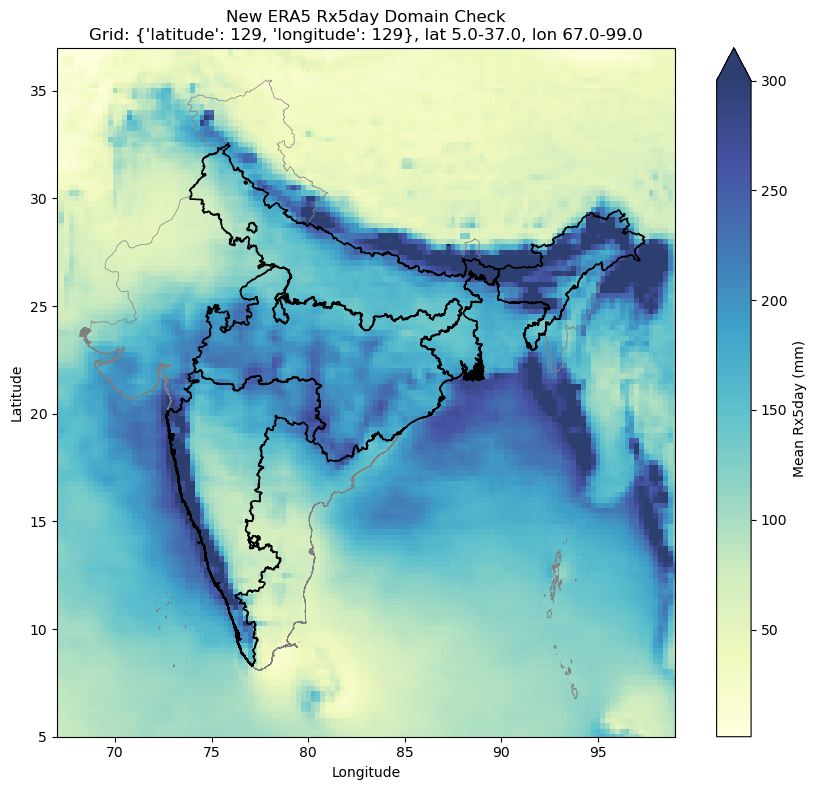

In [ ]:
# Load the newly-extracted ERA5 Rx5day data
rx5day_era5_check = xr.open_dataarray(os.path.join(OUTPUT_DIR, 'rx5day_jjas_era5_1981_2023.nc'))

# Region boundaries for context
path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")
gdf_clean = gdf.dissolve(by="NAME_1")

region_states = {
    'Western_Ghats': ['Kerala', 'Karnataka', 'Goa', 'Maharashtra'],
    'Central_India': ['Madhya Pradesh', 'Chhattisgarh', 'Odisha', 'Jharkhand'],
    'Indo_Gangetic_Plain': ['Uttar Pradesh', 'Bihar', 'West Bengal', 'Punjab', 'Haryana'],
    'Northeast': ['Assam', 'Meghalaya', 'Arunachal Pradesh', 'Tripura']
}
state_to_region = {state: region for region, states in region_states.items() for state in states}
gdf_clean['region'] = gdf_clean.index.map(state_to_region)
gdf_regions = gdf_clean[gdf_clean['region'].notna()].dissolve(by='region')

# Plot mean Rx5day at native 0.25° resolution, showing full extent
fig, ax = plt.subplots(figsize=(9, 8))

mean_map = rx5day_era5_check.mean(dim='year')
im = ax.pcolormesh(mean_map.longitude, mean_map.latitude, mean_map, cmap='YlGnBu', shading='nearest', alpha=0.85, vmax=300)

gdf_clean.dissolve().boundary.plot(ax=ax, color='grey', linewidth=0.5)
for region in region_states.keys():
    gdf_regions.loc[[region]].boundary.plot(ax=ax, color='black', linewidth=1.2)

ax.set_xlim(float(mean_map.longitude.min()), float(mean_map.longitude.max()))
ax.set_ylim(float(mean_map.latitude.min()), float(mean_map.latitude.max()))
ax.set_title(f'New ERA5 Rx5day Domain Check\nGrid: {dict(mean_map.sizes)}, lat {float(mean_map.latitude.min()):.1f}-{float(mean_map.latitude.max()):.1f}, lon {float(mean_map.longitude.min()):.1f}-{float(mean_map.longitude.max()):.1f}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(im, ax=ax, label='Mean Rx5day (mm)', extend='max')
plt.tight_layout()
plt.show()

In [ ]:
# Locate the exact year/lat/lon of the max value
max_val = float(rx5day_era5.max())
loc = rx5day_era5.where(rx5day_era5 == max_val, drop=True)
print(f'Max value: {max_val:.1f} mm')
print(loc.coords)

Max value: 1460.5 mm
Coordinates:
  * latitude   (latitude) float64 8B 18.25
  * longitude  (longitude) float64 8B 68.5
    number     int64 8B 0
  * year       (year) int64 8B 1996


In [ ]:
# Re-open safely with chunking + immediate subset to avoid crash
target_year = 1996
target_lat = 18.25
target_lon = 68.5
target_file = '/data/oacd/obs/ERA5/combined_1995_1999.nc'

ds_check = xr.open_dataset(target_file, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})

pr_check = ds_check['tp'].max(dim='time')
pr_check_point = pr_check.sel(latitude=target_lat, longitude=target_lon, method='nearest')
pr_check_point = pr_check_point * 1000

# Build combined boolean mask against the ORIGINAL valid_time, then apply once
year_mask = pr_check_point.valid_time.dt.year == target_year
month_mask = pr_check_point.valid_time.dt.month.isin([6, 7, 8, 9])
combined_mask = year_mask & month_mask

pr_check_jjas = pr_check_point.sel(valid_time=combined_mask)

pr_check_jjas = pr_check_jjas.compute()
ds_check.close()

df = pr_check_jjas.to_dataframe()[['tp']]
print(df.to_string())

/tmp/ipykernel_1254218/169326382.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds_check = xr.open_dataset(target_file, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/169326382.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds_check = xr.open_dataset(target_file, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/169326382.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds_check = xr.open_dataset(target_file, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


                    tp
valid_time            
1996-06-01    0.000000
1996-06-02    0.000000
1996-06-03    0.061512
1996-06-04    0.367165
1996-06-05    0.250340
1996-06-06    0.203609
1996-06-07    0.809193
1996-06-08    5.247116
1996-06-09    5.455971
1996-06-10   12.518883
1996-06-11   12.605667
1996-06-12   35.300255
1996-06-13   47.535419
1996-06-14  174.260620
1996-06-15  633.775696
1996-06-16  205.872055
1996-06-17  274.512756
1996-06-18  172.081940
1996-06-19    2.159119
1996-06-20    1.681328
1996-06-21    2.729416
1996-06-22    2.905369
1996-06-23    1.377583
1996-06-24    0.359535
1996-06-25    0.292301
1996-06-26    0.370026
1996-06-27    0.634193
1996-06-28    0.685692
1996-06-29    0.700951
1996-06-30    1.245975
1996-07-01    2.021790
1996-07-02    1.954556
1996-07-03    1.800060
1996-07-04    0.274181
1996-07-05    0.543118
1996-07-06    1.829624
1996-07-07    2.297878
1996-07-08    1.605511
1996-07-09    3.759384
1996-07-10    7.238388
1996-07-11    1.574039
1996-07-12 

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
<h2 style="color:white;">Region-Selection Rationale: JJAS Climatology Map & Seasonal Cycle</h2>
<p style="color:#cce0ff;">Building the region-rationale figure: (A) mean JJAS precipitation climatology map with region boundaries overlaid, (B) mean monthly rainfall per region, 1981-2010 baseline -- to justify why these four regions represent genuinely distinct rainfall regimes.</p>
</div>

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import geopandas as gpd
import regionmask

ERA5_DIR = '/data/oacd/obs/ERA5/'
OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'

LAT_MAX, LAT_MIN = 37, 5
LON_MIN, LON_MAX = 67, 99

JJAS = [6, 7, 8, 9]
BASELINE_START = 1981
BASELINE_END = 2010

print('Config set for region-rationale figure')

Config set for region-rationale figure


In [ ]:
all_files = sorted(glob.glob(os.path.join(ERA5_DIR, 'combined_*.nc')))
needed_files = []
for f in all_files:
    basename = os.path.basename(f)
    start_yr = int(basename.split('_')[1])
    end_yr = int(basename.split('_')[2].replace('.nc', ''))
    if start_yr <= BASELINE_END and end_yr >= BASELINE_START:
        needed_files.append(f)

print(f'Files needed for 1981-2010 baseline: {len(needed_files)}')

Files needed for 1981-2010 baseline: 7


In [ ]:
probe = xr.open_dataset(needed_files[0])
probe_lats = probe.latitude.sel(latitude=slice(LAT_MAX, LAT_MIN)).values
probe_lons = probe.longitude.sel(longitude=slice(LON_MIN, LON_MAX)).values
probe.close()

path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")
gdf_clean = gdf.dissolve(by="NAME_1")

region_states = {
    'Western_Ghats': ['Kerala', 'Karnataka', 'Goa', 'Maharashtra'],
    'Central_India': ['Madhya Pradesh', 'Chhattisgarh', 'Odisha', 'Jharkhand'],
    'Indo_Gangetic_Plain': ['Uttar Pradesh', 'Bihar', 'West Bengal', 'Punjab', 'Haryana'],
    'Northeast': ['Assam', 'Meghalaya', 'Arunachal Pradesh', 'Tripura']
}
state_to_region = {state: region for region, states in region_states.items() for state in states}
gdf_clean['region'] = gdf_clean.index.map(state_to_region)
gdf_regions = gdf_clean[gdf_clean['region'].notna()].dissolve(by='region')
region_names = gdf_regions.index.tolist()

regions_mask_obj = regionmask.Regions(
    gdf_regions.geometry.tolist(), names=region_names, abbrevs=[r[:3] for r in region_names]
)

frac_overlap_era5 = regions_mask_obj.mask_3D_frac_approx(probe_lons, probe_lats)
frac_overlap_era5 = frac_overlap_era5.assign_coords(region=region_names)
frac_overlap_era5 = frac_overlap_era5.rename({'lat': 'latitude', 'lon': 'longitude'})

frac_overlap_era5.to_dataset(name='frac_overlap_era5').to_netcdf(OUTPUT_DIR + 'frac_overlap_era5.nc')
print('Region mask built and saved. Dims:', frac_overlap_era5.dims)

Region mask built and saved. Dims: ('region', 'latitude', 'longitude')


In [ ]:
def extract_era5_monthly_climatology(filepath):
    print(f'  Opening {os.path.basename(filepath)}...')
    ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})

    pr = ds['tp'].max(dim='time')
    pr_india = pr.sel(latitude=slice(LAT_MAX, LAT_MIN), longitude=slice(LON_MIN, LON_MAX))
    pr_india = pr_india * 1000  # metres -> mm

    pr_baseline = pr_india.sel(valid_time=pr_india.valid_time.dt.year.isin(
        range(BASELINE_START, BASELINE_END + 1)
    ))

    if len(pr_baseline.valid_time) == 0:
        print(f'  No data in baseline range, skipping')
        return None

    print(f'  Computing India subset...')
    pr_baseline = pr_baseline.compute()
    ds.close()
    return pr_baseline

print('Extraction function defined')

Extraction function defined


In [ ]:
print('Extracting ERA5 daily precip, all months, 1981-2010 baseline\n')

all_baseline = []
for filepath in needed_files:
    pr = extract_era5_monthly_climatology(filepath)
    if pr is not None:
        all_baseline.append(pr)

pr_baseline_all = xr.concat(all_baseline, dim='valid_time').sortby('valid_time')
print(f'Total days: {len(pr_baseline_all.valid_time)}')

pr_baseline_all.to_dataset(name='pr_daily').to_netcdf(OUTPUT_DIR + 'era5_baseline_daily_allmonths.nc')
print('Saved baseline daily precip for reuse')

Extracting ERA5 daily precip, all months, 1981-2010 baseline

  Opening combined_1980_1984.nc...
  Computing India subset...


/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Opening combined_1985_1989.nc...
  Computing India subset...


/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Opening combined_1990_1994.nc...
  Computing India subset...


...

  Opening combined_2005_2009.nc...
  Computing India subset...


/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


  Opening combined_2010_2014.nc...
  Computing India subset...


/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})
/tmp/ipykernel_1254218/3207983958.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(filepath, chunks={'valid_time': 30, 'latitude': 100, 'longitude': 100})


Total days: 10957
Saved baseline daily precip for reuse


In [ ]:
jjas_mask = pr_baseline_all.valid_time.dt.month.isin(JJAS)
jjas_climatology_map = pr_baseline_all.sel(valid_time=jjas_mask).mean(dim='valid_time')

monthly_regional = {}
for region in region_names:
    weights = frac_overlap_era5.sel(region=region)
    regional_daily = (pr_baseline_all * weights).sum(dim=['latitude', 'longitude']) / weights.sum()
    monthly_regional[region] = regional_daily.groupby('valid_time.month').mean()

print('Computed JJAS climatology map and monthly seasonal cycle per region')

Computed JJAS climatology map and monthly seasonal cycle per region


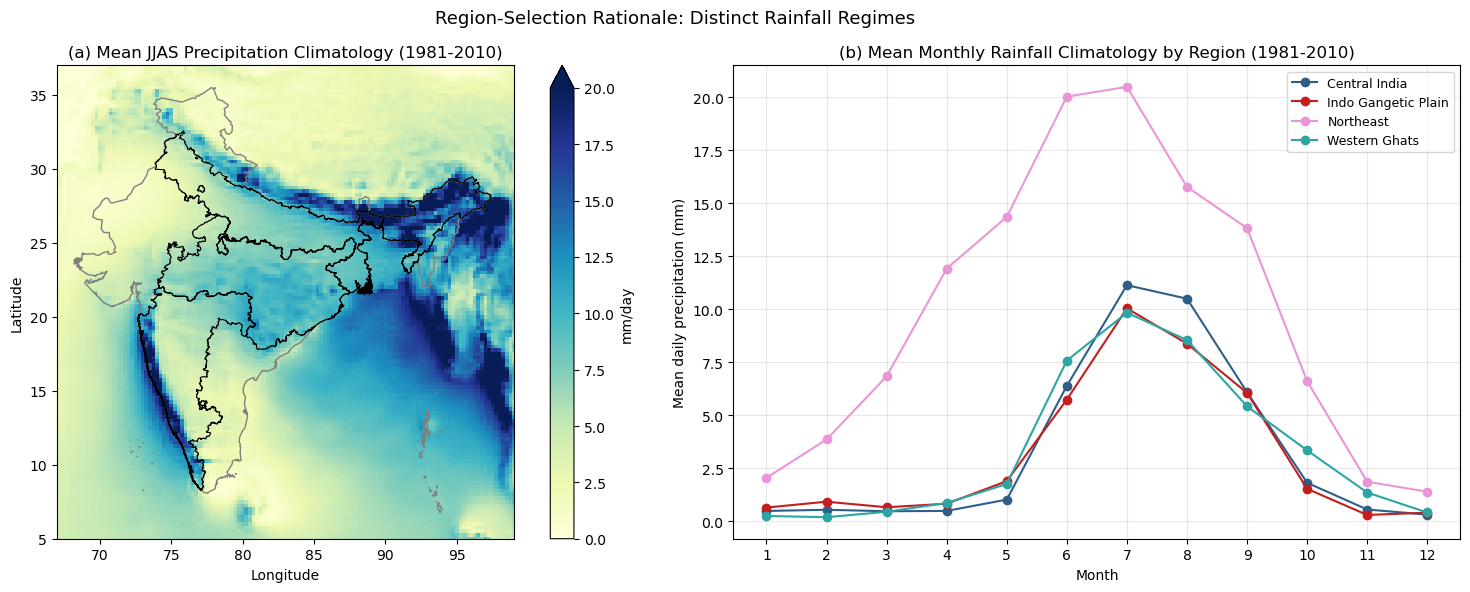

In [ ]:
REGION_COLORS = {
    'Western_Ghats': '#2CA6A4',
    'Central_India': '#2E5F8A',
    'Indo_Gangetic_Plain': '#C41E1E',
    'Northeast': '#E896D8'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

im = ax1.pcolormesh(jjas_climatology_map.longitude, jjas_climatology_map.latitude,
                     jjas_climatology_map, cmap='YlGnBu', shading='nearest', vmin=0, vmax=20)

india_outline = gdf_clean.dissolve().simplify(0.05).boundary
india_outline.plot(ax=ax1, color='grey', linewidth=1, zorder=1)

for region in region_names:
    gdf_regions.loc[[region]].boundary.plot(ax=ax1, color='black', linewidth=0.8, zorder=2)

ax1.set_xlim(LON_MIN, LON_MAX)
ax1.set_ylim(LAT_MIN, LAT_MAX)

ax1.set_title('(a) Mean JJAS Precipitation Climatology (1981-2010)')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.colorbar(im, ax=ax1, label='mm/day', extend='max')

for region in region_names:
    ax2.plot(monthly_regional[region].month, monthly_regional[region], marker='o',
              color=REGION_COLORS.get(region), label=region.replace('_', ' '))
ax2.set_xticks(range(1, 13))
ax2.set_xlabel('Month')
ax2.set_ylabel('Mean daily precipitation (mm)')
ax2.set_title('(b) Mean Monthly Rainfall Climatology by Region (1981-2010)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle('Region-Selection Rationale: Distinct Rainfall Regimes', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure_region_rationale.png', dpi=150, bbox_inches='tight')
plt.show()